# Stage S7 - Système embarqué IA + IHM Web

**Objectif :** Détecter et caractériser les épisodes de miction à partir de signaux audio enregistrés.

## Installation des dépendances

In [1]:
import sys

# Vérification des packages clés
packages = ['librosa', 'numpy', 'scipy', 'matplotlib', 'sklearn', 'pandas']
for pkg in packages:
    try:
        __import__(pkg)
        print(f'{pkg}')
    except ImportError:
        print(f' {pkg} – lancez : conda install {pkg}')
%matplotlib notebook

librosa
numpy
scipy
matplotlib
sklearn
pandas


##  Imports necessaires

In [2]:
import os
import json
import numpy as np
import pandas as pd
import scipy.io.wavfile as wav
import scipy.signal as signal
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from dataclasses import dataclass, asdict, field
from typing import List, Tuple, Optional
from IPython.display import Audio, display

try:
    from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
    from sklearn.preprocessing import StandardScaler, LabelEncoder
    from sklearn.model_selection import LeaveOneOut, cross_val_score
    from sklearn.metrics import classification_report, confusion_matrix
    import sklearn
    HAS_SKLEARN = True
    import librosa
    import librosa.display
    HAS_LIBROSA = True
except ImportError:
    HAS_SKLEARN = False
    HAS_LIBROSA = False
    print(' sklearn absent')


In [3]:
from pathlib import Path

raw_files = list(Path("C:/Users/asalou/S7/stages7/project/raw_audio").glob("*"))
print(f"{len(raw_files)} fichiers trouvés :")


22 fichiers trouvés :


## Conversion vers WAV

In [4]:
import librosa
import soundfile as sf
from pathlib import Path
import os

RAW_DIR = Path("C:/Users/asalou/S7/stages7/project/raw_audio")
WAV_DIR = Path("C:/Users/asalou/S7/stages7/project/wav_audio")

os.makedirs(WAV_DIR, exist_ok=True)

# Hz – fréquence d'échantillonnage cible
TARGET_SR = 16000

for file in RAW_DIR.glob("*"):
    if file.suffix.lower() in [".m4a", ".mp3", ".wav"]:
        print("Conversion :", file.name)
        
        y, sr = librosa.load(file, sr=TARGET_SR, mono=True)
        
        # Normalisation [-1,1]
        y = y / (abs(y).max() + 1e-9)
        
        out_path = WAV_DIR / (file.stem + ".wav")
        sf.write(out_path, y, TARGET_SR)
        
        print(" Sauvegardé :", out_path.name)

print("Conversion terminée ")

Conversion : Audio_1.m4a


C:\Users\asalou\AppData\Local\Temp\ipykernel_26212\440856491.py:18: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(file, sr=TARGET_SR, mono=True)
C:\Users\asalou\S7\envs\stages7\lib\site-packages\librosa\core\audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


 Sauvegardé : Audio_1.wav
Conversion : Audio_10.m4a


C:\Users\asalou\AppData\Local\Temp\ipykernel_26212\440856491.py:18: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(file, sr=TARGET_SR, mono=True)
C:\Users\asalou\S7\envs\stages7\lib\site-packages\librosa\core\audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


 Sauvegardé : Audio_10.wav
Conversion : Audio_11.m4a
 Sauvegardé : Audio_11.wav
Conversion : Audio_12.m4a
 Sauvegardé : Audio_12.wav
Conversion : Audio_13.m4a
 Sauvegardé : Audio_13.wav
Conversion : Audio_14.m4a
 Sauvegardé : Audio_14.wav
Conversion : Audio_15.m4a
 Sauvegardé : Audio_15.wav
Conversion : Audio_16.m4a
 Sauvegardé : Audio_16.wav
Conversion : Audio_17.m4a
 Sauvegardé : Audio_17.wav
Conversion : Audio_18.m4a
 Sauvegardé : Audio_18.wav
Conversion : Audio_19.m4a
 Sauvegardé : Audio_19.wav
Conversion : Audio_2.m4a
 Sauvegardé : Audio_2.wav
Conversion : Audio_20.m4a
 Sauvegardé : Audio_20.wav
Conversion : Audio_3.m4a
 Sauvegardé : Audio_3.wav
Conversion : Audio_4.m4a
 Sauvegardé : Audio_4.wav
Conversion : Audio_5.m4a
 Sauvegardé : Audio_5.wav
Conversion : Audio_6.m4a
 Sauvegardé : Audio_6.wav
Conversion : Audio_7.m4a
 Sauvegardé : Audio_7.wav
Conversion : Audio_8.m4a
 Sauvegardé : Audio_8.wav
Conversion : Audio_9.m4a
 Sauvegardé : Audio_9.wav
Conversion : Bruit de pipi (mp3cut.

 ## CHARGEMENT DATASET

In [5]:
dataset = {}

for file in WAV_DIR.glob("*.wav"):
    y, sr = librosa.load(file, sr=16000)

    dataset[file.stem] = {
        'data': y,
        'filtered': y.copy(),   
        'sr': sr,
        'duration': len(y)/sr,
        'energy': None,
        'times': None,
        'threshold': None,
        'segments': []
    }
print("Dataset chargé :", len(dataset))
# Paramètres audio
TARGET_SR  = 16000
HP_CUTOFF  = 100
LP_CUTOFF  = 6000
FRAME_MS   = 30
HOP_MS     = 10
N_MFCC     = 13
N_MELS     = 64

Dataset chargé : 21


## Analyse fréquentielle réelle d’une miction

Durée : 48.469375 secondes


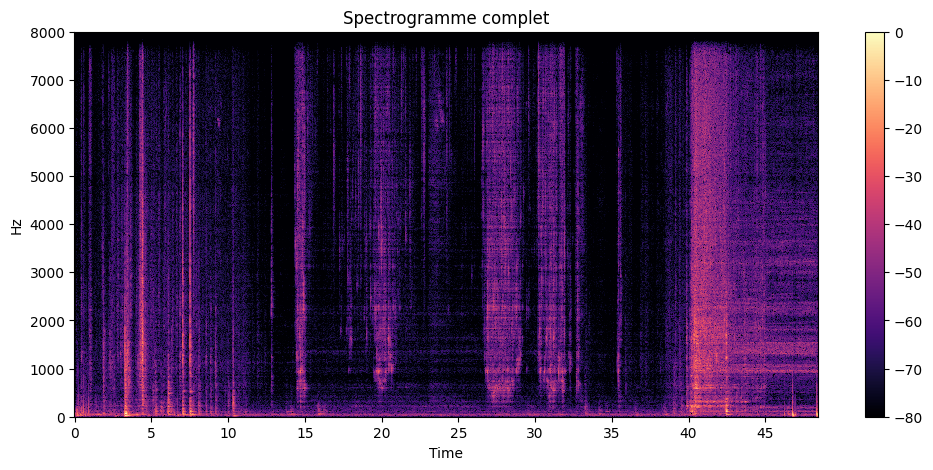

In [19]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch
from pathlib import Path
import librosa.display

file = Path("C:/Users/asalou/S7/stages7/project/wav_audio/Audio_2.wav")

y, sr = librosa.load(file, sr=16000)

print("Durée :", len(y)/sr, "secondes")

# Spectrogramme
plt.figure(figsize=(12,5))
D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='hz')
plt.colorbar()
plt.title("Spectrogramme complet")
plt.ylim(0, 8000)
plt.show()

 ## Extraction de la miction

Durée segment : 17.0 secondes


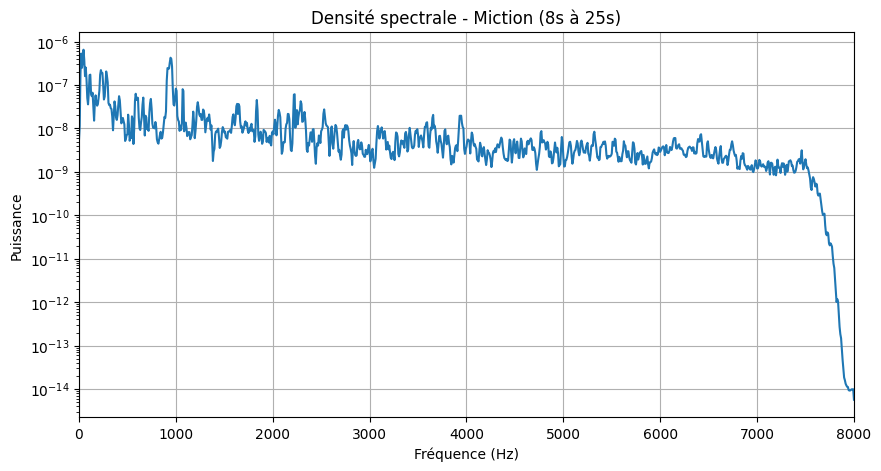

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

# Segment miction
start = 8
end = 25

y_segment = y[int(start*sr):int(end*sr)]

print("Durée segment :", len(y_segment)/sr, "secondes")

# Densité spectrale de puissance (PSD)
f, Pxx = welch(y_segment, sr, nperseg=2048)

plt.figure(figsize=(10,5))
plt.semilogy(f, Pxx)
plt.title("Densité spectrale - Miction (8s à 25s)")
plt.xlabel("Fréquence (Hz)")
plt.ylabel("Puissance")
plt.xlim(0, 8000)
plt.grid()
plt.show()

L’analyse spectrale du signal de miction montre que l’énergie acoustique est principalement distribuée entre 200 Hz et 5 kHz, avec une concentration notable entre 300 Hz et 4 kHz.
Les basses fréquences (<100 Hz) présentent une contribution limitée, tandis que les hautes fréquences au-delà de 6 kHz sont négligeables.

## Filtrage passe-bande

Le son de la miction (jet d'eau dans une cuvette) concentre son énergie entre **200 Hz et 5 kHz**.
On applique un filtre de Butterworth passe-bande pour supprimer :
- Les basses fréquences (< 100 Hz) : bruits mécaniques, ventilation
- Les hautes fréquences (> 6 kHz) : artefacts électroniques

In [8]:
# Paramètres 
HP_CUTOFF     = 100     # Hz – filtre passe-haut
LP_CUTOFF     = 6000    # Hz – filtre passe-bas

def bandpass_filter(data: np.ndarray, sr: int,
                     lo: float = HP_CUTOFF,
                     hi: float = LP_CUTOFF,
                     order: int = 5) -> np.ndarray:
    """Filtre passe-bande de Butterworth."""
    nyq  = sr / 2.0
    b, a = signal.butter(order, [lo/nyq, hi/nyq], btype='band')
    filt = signal.filtfilt(b, a, data)
    # re-normalise
    filt /= (np.max(np.abs(filt)) + 1e-9)  
    return filt.astype(np.float32)

def energy_envelope(data: np.ndarray, sr: int,
                    frame_ms: int = 30,
                    hop_ms: int   = 10) -> tuple:
    """Calcule l'énergie RMS par trame via fenêtre glissante."""
    frame_len = int(frame_ms * sr / 1000)
    hop_len   = int(hop_ms  * sr / 1000)
    n_frames  = 1 + (len(data) - frame_len) // hop_len
    frames    = np.lib.stride_tricks.sliding_window_view(data, frame_len)[::hop_len]
    frames    = frames[:n_frames]
    energy    = np.sqrt(np.mean(frames**2, axis=1))
    times     = np.arange(len(energy)) * hop_len / sr
    return energy, times


# Appliquer à tous les fichiers
for name, rec in dataset.items():
    rec['filtered'] = bandpass_filter(rec['data'], rec['sr'])

print('Filtre passe-bande appliqué à tous les enregistrements')
print(f'   Bande passante : {HP_CUTOFF} Hz – {LP_CUTOFF} Hz | Ordre {5} | Butterworth')


Filtre passe-bande appliqué à tous les enregistrements
   Bande passante : 100 Hz – 6000 Hz | Ordre 5 | Butterworth


#  Analyse exploratoire des phases de la miction


C:\Users\asalou\AppData\Local\Temp\ipykernel_26212\2859961227.py:73: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


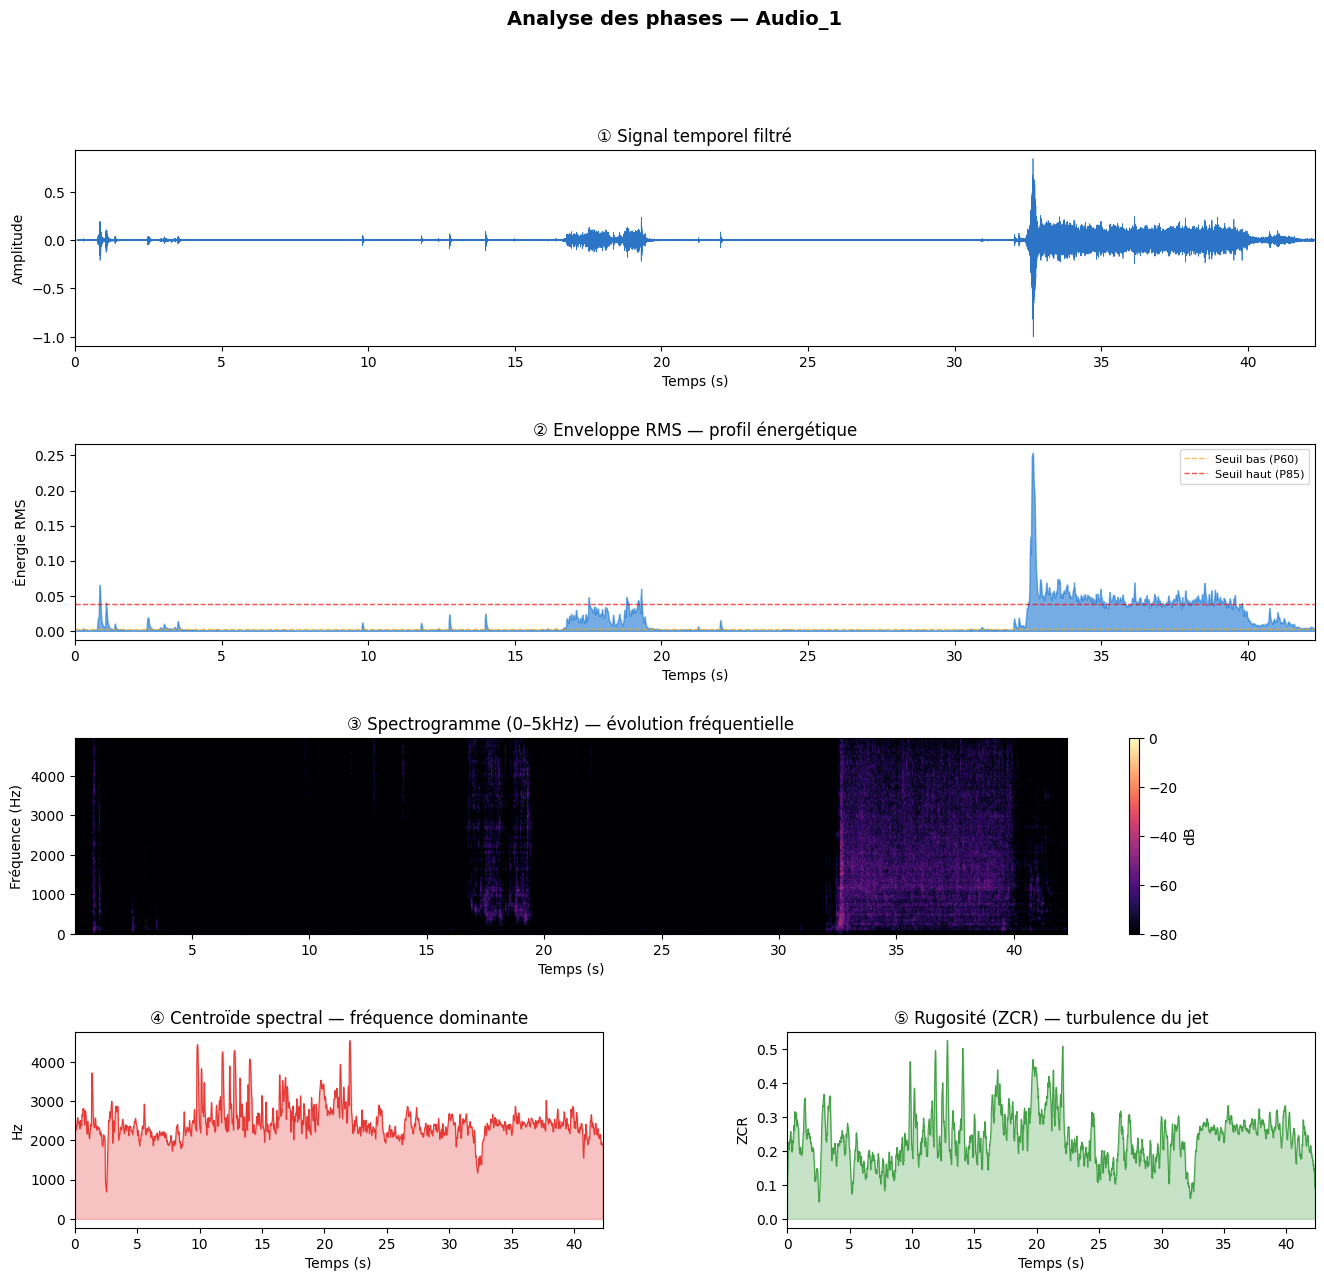

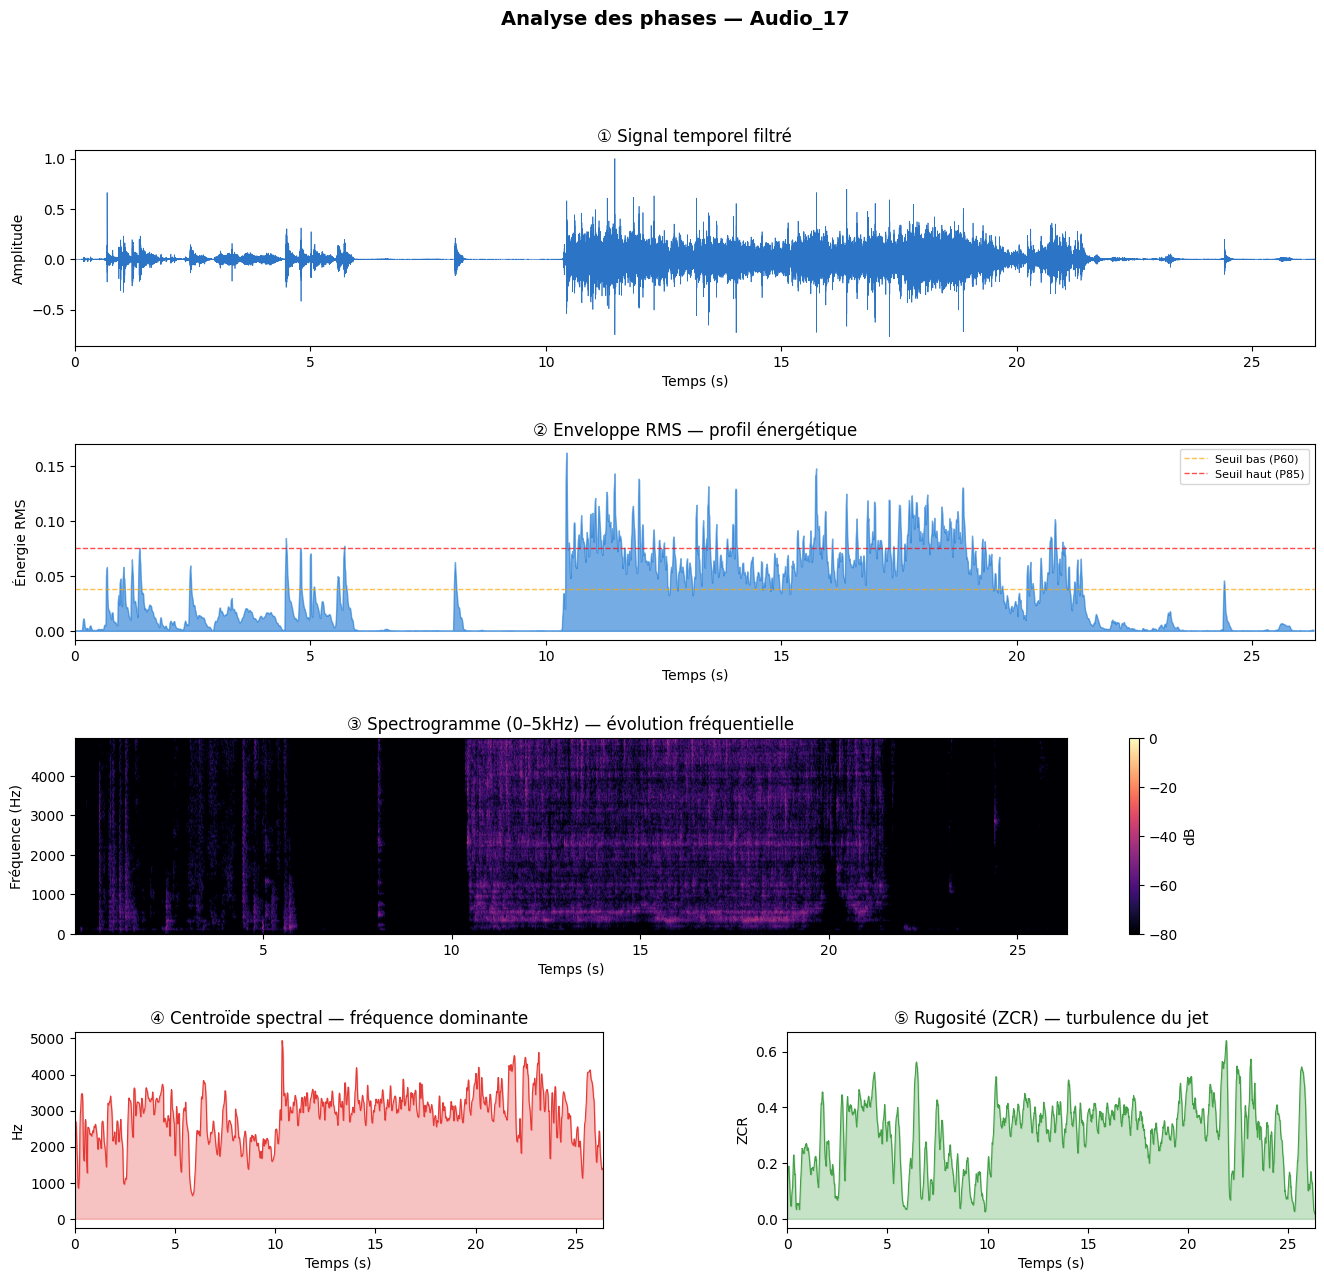

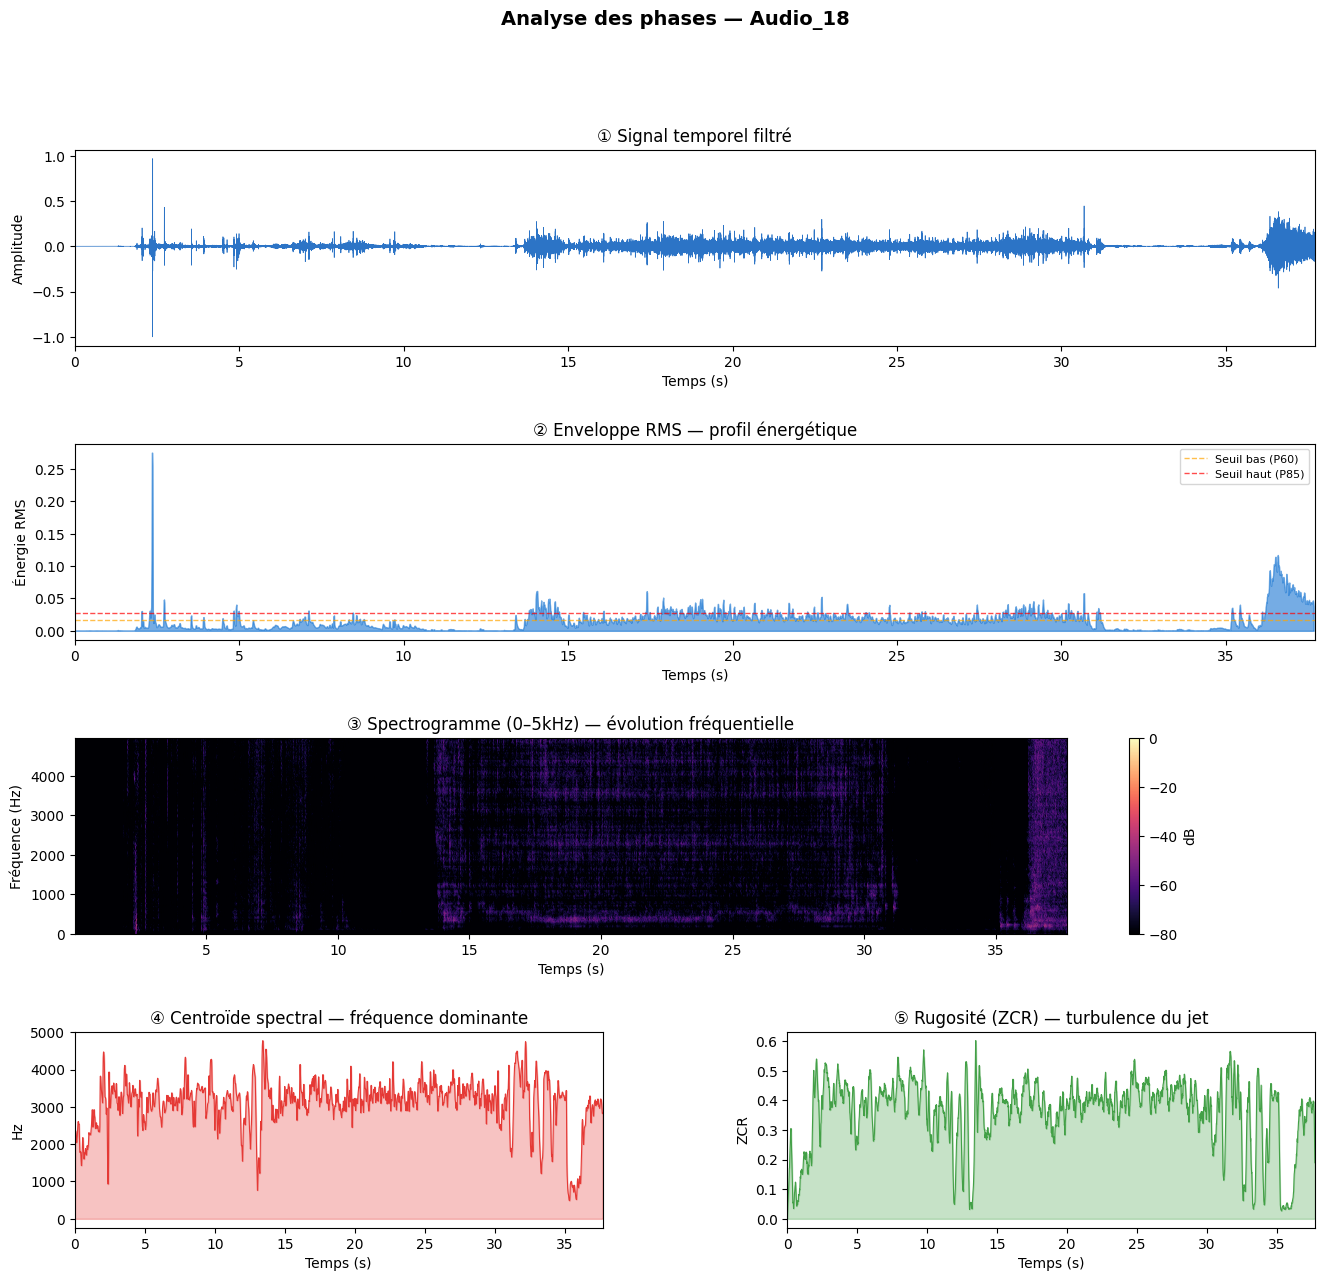

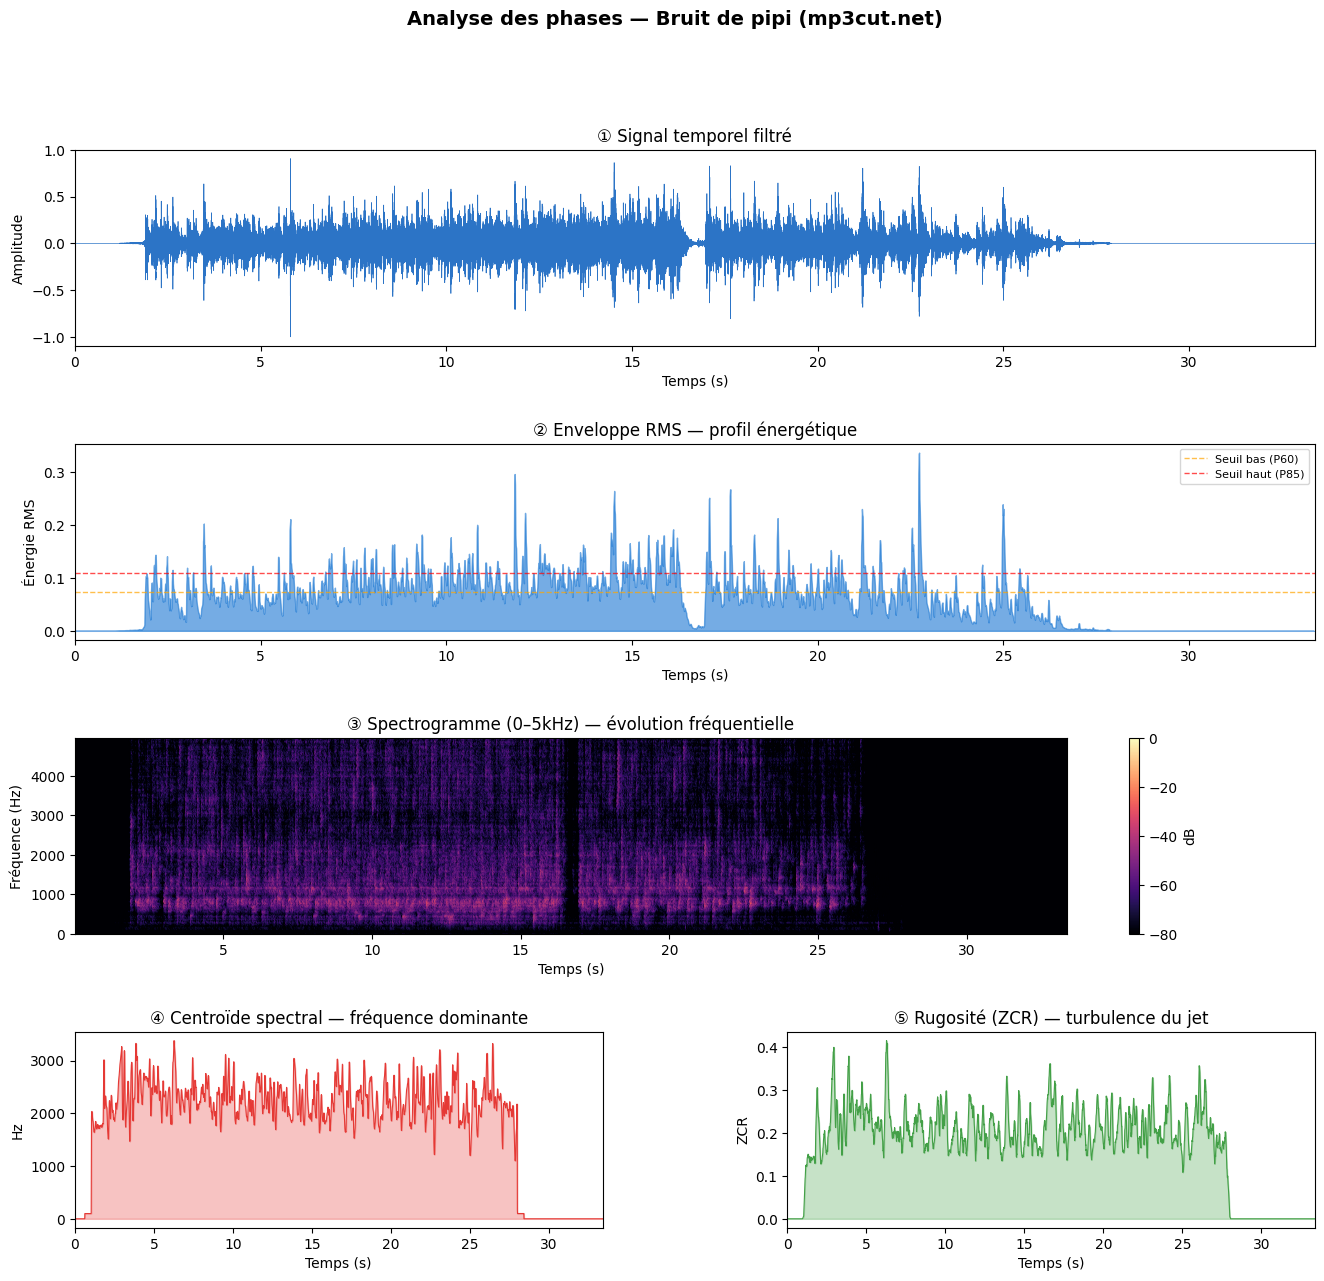

In [21]:

def analyse_phases(name: str, rec: dict, save: bool = True):
    """
    Génère un rapport visuel complet pour identifier
    les phases d'un enregistrement de miction.
    """
    data = rec['data']
    filt = rec['filtered']
    sr   = rec['sr']
    t    = np.linspace(0, rec['duration'], len(data))

    fig = plt.figure(figsize=(16, 14))
    fig.suptitle(f'Analyse des phases — {name}', fontsize=14, fontweight='bold')
    gs  = gridspec.GridSpec(4, 2, figure=fig, hspace=0.5, wspace=0.35)

    # ── 1. Signal temporel ────────────────────────────────────────
    ax1 = fig.add_subplot(gs[0, :])
    ax1.plot(t, filt, color='#1565C0', lw=0.5, alpha=0.9)
    ax1.set_title('① Signal temporel filtré')
    ax1.set_xlabel('Temps (s)'); ax1.set_ylabel('Amplitude')
    ax1.set_xlim(0, rec['duration'])

    # ── 2. Enveloppe RMS ──────────────────────────────────────────
    ax2 = fig.add_subplot(gs[1, :])
    energy, times = energy_envelope(filt, sr)
    ax2.fill_between(times, energy, alpha=0.6, color='#1976D2')
    ax2.set_title('② Enveloppe RMS — profil énergétique')
    ax2.set_xlabel('Temps (s)'); ax2.set_ylabel('Énergie RMS')
    ax2.set_xlim(0, rec['duration'])

    # Annoter les phases automatiquement par seuillage simple
    thr_low  = np.percentile(energy, 60)
    thr_high = np.percentile(energy, 85)
    ax2.axhline(thr_low,  color='orange', ls='--', lw=1, alpha=0.7, label='Seuil bas (P60)')
    ax2.axhline(thr_high, color='red',    ls='--', lw=1, alpha=0.7, label='Seuil haut (P85)')
    ax2.legend(fontsize=8)

    # ── 3. Spectrogramme ─────────────────────────────────────────
    ax3 = fig.add_subplot(gs[2, :])
    f_s, t_s, Sxx = signal.spectrogram(filt, sr, nperseg=512, noverlap=448)
    idx = np.searchsorted(f_s, 5000)
    im  = ax3.pcolormesh(t_s, f_s[:idx], 10*np.log10(Sxx[:idx]+1e-10),
                          shading='gouraud', cmap='magma', vmin=-80, vmax=0)
    plt.colorbar(im, ax=ax3, label='dB')
    ax3.set_title('③ Spectrogramme (0–5kHz) — évolution fréquentielle')
    ax3.set_xlabel('Temps (s)'); ax3.set_ylabel('Fréquence (Hz)')

    # ── 4. Centroïde spectral ─────────────────────────────────────
    ax4 = fig.add_subplot(gs[3, 0])
    if HAS_LIBROSA:
        sc = librosa.feature.spectral_centroid(
                y=filt, sr=sr,
                hop_length=int(HOP_MS*sr/1000))[0]
        t_sc = np.linspace(0, rec['duration'], len(sc))
        ax4.plot(t_sc, sc, color='#E53935', lw=0.8)
        ax4.fill_between(t_sc, sc, alpha=0.3, color='#E53935')
    ax4.set_title('④ Centroïde spectral — fréquence dominante')
    ax4.set_xlabel('Temps (s)'); ax4.set_ylabel('Hz')
    ax4.set_xlim(0, rec['duration'])

    # ── 5. Rugosité (ZCR) ─────────────────────────────────────────
    ax5 = fig.add_subplot(gs[3, 1])
    if HAS_LIBROSA:
        zcr = librosa.feature.zero_crossing_rate(
                filt,
                hop_length=int(HOP_MS*sr/1000))[0]
        t_zcr = np.linspace(0, rec['duration'], len(zcr))
        ax5.plot(t_zcr, zcr, color='#43A047', lw=0.8)
        ax5.fill_between(t_zcr, zcr, alpha=0.3, color='#43A047')
    ax5.set_title('⑤ Rugosité (ZCR) — turbulence du jet')
    ax5.set_xlabel('Temps (s)'); ax5.set_ylabel('ZCR')
    ax5.set_xlim(0, rec['duration'])

    plt.tight_layout()
    if save:
        path = f'{WAV_DIR}/{name}_phases.png'
        plt.savefig(path, dpi=120, bbox_inches='tight')
    plt.show()
    plt.close()


# ── Lancer sur 4 enregistrements représentatifs ──────────────────
for nom in ['Audio_1', 'Audio_17', 'Audio_18', 'Bruit de pipi (mp3cut.net)']:
    analyse_phases(nom, dataset[nom])

# LABÉLISATION — Approche par plages temporelles

In [10]:
%matplotlib inline
import ipywidgets as widgets
from IPython.display import display, clear_output, Audio
import json, os
import numpy as np

SEGMENT_MS  = 500
LABELS_LIST = ['silence', 'bruit_ambiant', 'miction_active', 'fin_jet','bruit_chasse']
COLORS      = {
    'silence':    '#90A4AE',
    'bruit_ambiant': '#FF7043', 
    'miction_active': '#43A047',
    'fin_jet':    '#AB47BC',
    'bruit_chasse': '#00BCD4',  
}
LAB_DIR = Path("C:/Users/asalou/S7/stages7/project/labels")
SAVE_PATH   = f'{LAB_DIR}/labels_segments.json'

# Charger labels existants
if os.path.exists(SAVE_PATH):
    with open(SAVE_PATH) as f:
        all_labels = json.load(f)
    print(f'Labels chargés')
else:
    all_labels = {}
    print('📋 Nouveau fichier de labels')


def save_labels():
    with open(SAVE_PATH, 'w') as f:
        json.dump(all_labels, f, indent=2)


def segmenter(data, sr, segment_ms=SEGMENT_MS):
    seg_len = int(segment_ms * sr / 1000)
    n_segs  = len(data) // seg_len
    times   = [round(i * segment_ms / 1000, 3) for i in range(n_segs)]
    return n_segs, times, seg_len


# ── État global ───────────────────────────────────────────────
state = {'name': None, 'seg_labels': [], 'times': [], 'n_segs': 0}

# ── Widgets principaux ────────────────────────────────────────
file_names = sorted(dataset.keys())
w_file = widgets.Dropdown(options=file_names, description='Fichier:',
                           layout=widgets.Layout(width='320px'))

# Boutons labels
btns_label = []
for lbl in LABELS_LIST:
    b = widgets.ToggleButton(
        value=(lbl == 'silence'),
        description=lbl,
        style={'button_color': COLORS[lbl]},
        layout=widgets.Layout(width='120px', height='36px')
    )
    btns_label.append(b)

w_label_actif = widgets.Label('Label actif : silence', 
                               style={'font_weight':'bold'})

# Slider pour naviguer segment par segment
w_slider = widgets.IntSlider(
    min=0, max=1, value=0,
    description='Segment:',
    continuous_update=False,
    layout=widgets.Layout(width='600px')
)

# Plage : appliquer un label à plusieurs segments d'un coup
w_t_debut = widgets.BoundedFloatText(
    value=0.0, min=0.0, max=300.0, step=0.5,
    description='De (s):',
    layout=widgets.Layout(width='160px')
)
w_t_fin = widgets.BoundedFloatText(
    value=0.5, min=0.0, max=300.0, step=0.5,
    description='À (s):',
    layout=widgets.Layout(width='160px')
)

btn_appliquer = widgets.Button(
    description=' Appliquer plage',
    style={'button_color': '#1976D2'},
    layout=widgets.Layout(width='160px')
)

w_info   = widgets.HTML('')
w_plot   = widgets.Output()
w_status = widgets.Label('')
def appliquer_plage(b):
    if not state['name']:
        return
    lbl   = get_label_actif()
    seg_s = SEGMENT_MS / 1000

    # Conversion secondes → indices segments
    seg_deb = int(w_t_debut.value / seg_s)
    seg_fin = int(w_t_fin.value   / seg_s)

    # Sécurité bornes
    seg_deb = max(0, seg_deb)
    seg_fin = min(seg_fin, state['n_segs'] - 1)

    for i in range(seg_deb, seg_fin + 1):
        state['seg_labels'][i] = lbl
    all_labels[state['name']] = state['seg_labels']

    n_labeled = sum(1 for l in state['seg_labels'] if l != 'silence')
    w_info.value = (
        f'<b>{state["name"]}</b> — {state["n_segs"]} segments '
        f'| <b>{n_labeled} non-silence</b> '
        f'|  [{w_t_debut.value}s → {w_t_fin.value}s] = {lbl} '
        f'(segs {seg_deb}→{seg_fin})'
    )
    draw_plot()

btn_appliquer.on_click(appliquer_plage)


def get_label_actif():
    for i, b in enumerate(btns_label):
        if b.value:
            return LABELS_LIST[i]
    return 'silence'


def on_toggle(change):
    """Un seul bouton actif à la fois."""
    if change['new']:
        lbl = change['owner'].description
        for b in btns_label:
            if b.description != lbl:
                b.value = False
        w_label_actif.value = f'Label actif : {lbl}'

for b in btns_label:
    b.observe(on_toggle, names='value')


def draw_plot():
    """Redessine le spectrogramme + timeline."""
    with w_plot:
        clear_output(wait=True)
        name = state['name']
        if not name:
            return
        rec  = dataset[name]
        data = rec['filtered']
        sr   = rec['sr']
        dur  = rec['duration']
        seg_labels = state['seg_labels']
        times      = state['times']
        seg_s      = SEGMENT_MS / 1000

        fig, axes = plt.subplots(3, 1, figsize=(15, 7),
                                  gridspec_kw={'height_ratios': [1, 2.5, 0.8]})
        fig.suptitle(f'Labélisation — {name}  '
                     f'({state["n_segs"]} segments × {SEGMENT_MS}ms)',
                     fontsize=11, fontweight='bold')

        # Signal
        t = np.linspace(0, dur, len(data))
        axes[0].plot(t, data, color='#1565C0', lw=0.4)
        axes[0].set_xlim(0, dur); axes[0].set_ylabel('Amplitude', fontsize=8)
        axes[0].set_xticks([])

        # Spectrogramme
        f_s, t_s, Sxx = signal.spectrogram(data, sr, nperseg=512, noverlap=448)
        idx = np.searchsorted(f_s, 5000)
        axes[1].pcolormesh(t_s, f_s[:idx], 10*np.log10(Sxx[:idx]+1e-10),
                            shading='gouraud', cmap='magma', vmin=-80, vmax=0)
        axes[1].set_ylabel('Fréquence (Hz)', fontsize=8)
        axes[1].set_xlim(0, dur); axes[1].set_xticks([])

        # Overlay labels sur spectrogramme
        for i, (ts, lbl) in enumerate(zip(times, seg_labels)):
            axes[1].axvspan(ts, ts + seg_s, alpha=0.3, color=COLORS[lbl])

        # Segment courant en surbrillance
        cur = w_slider.value
        if 0 <= cur < len(times):
            axes[1].axvspan(times[cur], times[cur]+seg_s,
                             alpha=0.7, color='white',
                             linewidth=0, zorder=5)
            axes[1].axvline(times[cur], color='yellow', lw=1.5, zorder=6)

        # Légende
        from matplotlib.patches import Patch
        axes[1].legend(
            handles=[Patch(color=COLORS[l], label=l) for l in LABELS_LIST],
            loc='upper right', fontsize=7, framealpha=0.8)

        # Timeline
        for i, (ts, lbl) in enumerate(zip(times, seg_labels)):
            axes[2].barh(0, seg_s, left=ts, height=0.8,
                          color=COLORS[lbl], alpha=0.85)
        if 0 <= cur < len(times):
            axes[2].axvline(times[cur], color='yellow', lw=2)
        axes[2].set_xlim(0, dur)
        axes[2].set_yticks([])
        axes[2].set_xlabel('Temps (s)', fontsize=8)

        plt.tight_layout()
        plt.show()

# ── Mise à jour du max selon le fichier chargé ────────────────────
def charger_fichier(b=None):
    name = w_file.value
    rec  = dataset[name]
    n_segs, times, _ = segmenter(rec['filtered'], rec['sr'])

    state['name']   = name
    state['n_segs'] = n_segs
    state['times']  = times

    if name in all_labels and len(all_labels[name]) == n_segs:
        state['seg_labels'] = all_labels[name][:]
    else:
        state['seg_labels'] = ['silence'] * n_segs
        all_labels[name]    = state['seg_labels']

    # Mettre à jour les bornes max en secondes
    max_t = round(n_segs * SEGMENT_MS / 1000, 1)
    w_t_debut.max = max_t
    w_t_fin.max   = max_t
    w_t_debut.value = 0.0
    w_t_fin.value   = max_t

    n_labeled = sum(1 for l in state['seg_labels'] if l != 'silence')
    w_info.value = (
        f'<b>{name}</b> — {n_segs} segments × 500ms = {max_t}s total '
        f'| {n_labeled} non-silence'
    )
    draw_plot()


btn_charger = widgets.Button(
    description='Charger',
    button_style='success',
    layout=widgets.Layout(width='120px')
)

btn_charger.on_click(charger_fichier)

btn_save = widgets.Button(
    description='Sauvegarder labels',
    button_style='warning',
    layout=widgets.Layout(width='180px')
)

def on_save(b):
    save_labels()
    w_status.value = " Labels sauvegardés"

btn_save.on_click(on_save)

# ── Réassembler l'interface ───────────────────────────────────────
display(widgets.VBox([
    widgets.HTML('<h2> Outil de Labélisation — Segmentation 500ms</h2>'),
    widgets.HBox([w_file, btn_charger]),
    w_info,
    widgets.HTML('<b>① Sélectionnez un label :</b>'),
    widgets.HBox(btns_label),
    w_label_actif,
    widgets.HTML('<hr><b>② Appliquez à une plage en secondes :</b>'),
    widgets.HBox([w_t_debut, w_t_fin, btn_appliquer]),
    widgets.HTML('<hr>'),
    widgets.HBox([btn_save, w_status]),
    w_plot,
]))


Labels chargés


In [11]:
# ── Export CSV du dataset labélisé ───────────────────────────────
import pandas as pd

rows = []
for name, labels in all_labels.items():
    seg_s = SEGMENT_MS / 1000
    for i, lbl in enumerate(labels):
        t_start = round(i * seg_s, 3)
        t_end   = round((i+1) * seg_s, 3)
        rows.append({
            'fichier':    name,
            'segment_id': i,
            't_start_s':  t_start,
            't_end_s':    t_end,
            'duree_ms':   SEGMENT_MS,
            'label':      lbl,
        })

df_labels = pd.DataFrame(rows)

# Sauvegarder
csv_path = f'{LAB_DIR}/dataset_labels.csv'
df_labels.to_csv(csv_path, index=False, encoding='utf-8-sig')

print(f" CSV exporté : {csv_path}")
print(f"   {len(df_labels)} lignes × {len(df_labels.columns)} colonnes")
print(f"\nDistribution des labels :")
display(df_labels['label'].value_counts())

 CSV exporté : C:\Users\asalou\S7\stages7\project\labels/dataset_labels.csv
   1623 lignes × 6 colonnes

Distribution des labels :


label
miction_active    782
bruit_ambiant     463
bruit_chasse      222
silence           156
Name: count, dtype: int64

#  EXtraction des features

In [12]:
# ════════════════════════════════════════════════════════════════
# EXTRACTION DE FEATURES — Tous les segments labélisés
# ════════════════════════════════════════════════════════════════

def extract_features_segment(segment: np.ndarray, sr: int) -> dict:
    """
    Extrait les features audio d'un segment de 500ms.
    Entrée  : signal filtré du segment (8000 samples à 16kHz)
    Sortie  : dictionnaire de features numériques
    """
    hop = int(HOP_MS  * sr / 1000)   # 160 samples
    nfft= int(FRAME_MS * sr / 1000)  # 480 samples
    f   = {}

    # ── 1. MFCCs — texture timbrale ──────────────────────────────
    # 13 coefficients × (mean + std) = 26 features
    mfccs = librosa.feature.mfcc(y=segment, sr=sr, n_mfcc=N_MFCC,
                                   n_fft=nfft, hop_length=hop)
    for i in range(N_MFCC):
        f[f'mfcc_{i+1:02d}_mean'] = float(np.mean(mfccs[i]))
        f[f'mfcc_{i+1:02d}_std']  = float(np.std(mfccs[i]))

    # ── 2. RMS — énergie et stabilité ────────────────────────────
    rms = librosa.feature.rms(y=segment, hop_length=hop)[0]
    f['rms_mean'] = float(np.mean(rms))
    f['rms_std']  = float(np.std(rms))
    f['rms_max']  = float(np.max(rms))
    f['rms_min']  = float(np.min(rms))
    # Coefficient de variation → mesure la régularité du jet
    f['rms_cv']   = float(np.std(rms) / (np.mean(rms) + 1e-9))

    # ── 3. ZCR — rugosité / turbulence ───────────────────────────
    zcr = librosa.feature.zero_crossing_rate(segment, hop_length=hop)[0]
    f['zcr_mean'] = float(np.mean(zcr))
    f['zcr_std']  = float(np.std(zcr))

    # ── 4. Centroïde spectral — fréquence dominante ──────────────
    sc = librosa.feature.spectral_centroid(y=segment, sr=sr,
                                            n_fft=nfft, hop_length=hop)[0]
    f['spectral_centroid_mean'] = float(np.mean(sc))
    f['spectral_centroid_std']  = float(np.std(sc))

    # ── 5. Bandwidth spectral — largeur du spectre ───────────────
    bw = librosa.feature.spectral_bandwidth(y=segment, sr=sr,
                                             n_fft=nfft, hop_length=hop)[0]
    f['spectral_bandwidth_mean'] = float(np.mean(bw))
    f['spectral_bandwidth_std']  = float(np.std(bw))

    # ── 6. Rolloff spectral ──────────────────────────────────────
    ro = librosa.feature.spectral_rolloff(y=segment, sr=sr,
                                           n_fft=nfft, hop_length=hop)[0]
    f['spectral_rolloff_mean'] = float(np.mean(ro))
    f['spectral_rolloff_std']  = float(np.std(ro))

    return f


# ── Extraction sur tout le dataset labélisé ───────────────────────
rows_features = []
seg_len = int(SEGMENT_MS * TARGET_SR / 1000)  # 8000 samples

for name, rec in dataset.items():
    labels = all_labels.get(name, [])
    if not labels:
        print(f"  {name} : pas de labels — ignoré")
        continue

    data = rec['filtered']
    sr   = rec['sr']
    n_ok = 0

    for i, lbl in enumerate(labels):
        # Découper le segment
        start = i * seg_len
        end   = start + seg_len
        if end > len(data):
            break
        segment = data[start:end]

        # Extraire les features
        feats = extract_features_segment(segment, sr)

        # Construire la ligne
        row = {
            'fichier':    name,
            'segment_id': i,
            't_start_s':  round(i * SEGMENT_MS / 1000, 3),
            't_end_s':    round((i+1) * SEGMENT_MS / 1000, 3),
            'label':      lbl,
        }
        row.update(feats)
        rows_features.append(row)
        n_ok += 1

# ── Construire le DataFrame ───────────────────────────────────────
df_features = pd.DataFrame(rows_features)

print(f"\n{'='*60}")
print(f"Total : {len(df_features)} segments")
print(f"   {len(df_features.columns)-5} features par segment")
print(f"   Distribution des labels :")
print(df_features['label'].value_counts().to_string())


Total : 1623 segments
   39 features par segment
   Distribution des labels :
label
miction_active    782
bruit_ambiant     463
bruit_chasse      222
silence           156


In [13]:
# ── Fusionner fin_jet → miction_active dans le DataFrame ─────
df_features['label'] = df_features['label'].replace('fin_jet', 'miction_active')

# Mettre à jour y
y_final = df_features['label'].values

In [14]:
# ── 1. Mettre à jour labels_check en mémoire ─────────────────
for name in all_labels:
    all_labels[name] = [
        'miction_active' if l == 'fin_jet' else l 
        for l in all_labels[name]
    ]

# ── 2. Sauvegarder le JSON mis à jour ────────────────────────
save_labels()

# ── 3. Vérifier que fin_jet a disparu ────────────────────────
print("Vérification all_labels :")
for name, labels in all_labels.items():
    if 'fin_jet' in labels:
        print(f"  {name} : fin_jet encore présent !")
        
totaux = {}
for name, labels in all_labels.items():
    for l in labels:
        totaux[l] = totaux.get(l, 0) + 1
print("\nDistribution finale labels :")
for lbl, count in sorted(totaux.items(), key=lambda x: -x[1]):
    print(f"  {lbl:20s} : {count}")


Vérification all_labels :

Distribution finale labels :
  miction_active       : 782
  bruit_ambiant        : 463
  bruit_chasse         : 222
  silence              : 156


# VISUALISATION — tSNE

Calcul tSNE (patience ~30s)...
tSNE terminé — KL divergence : 0.9782


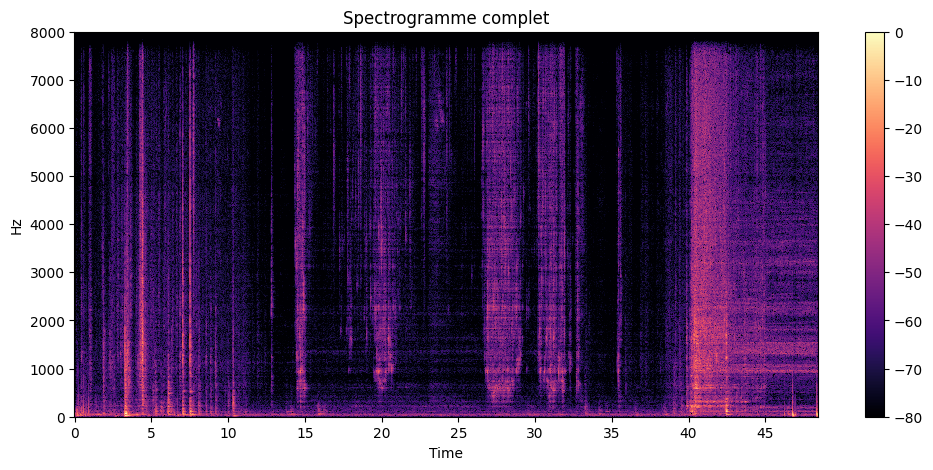

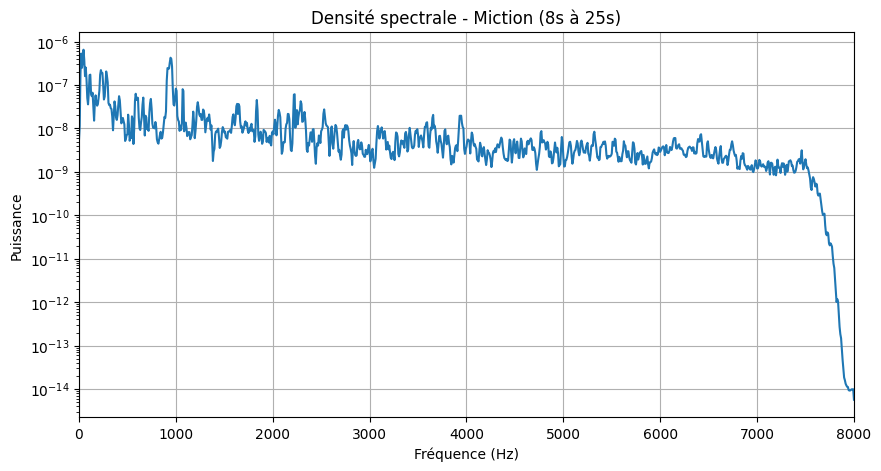

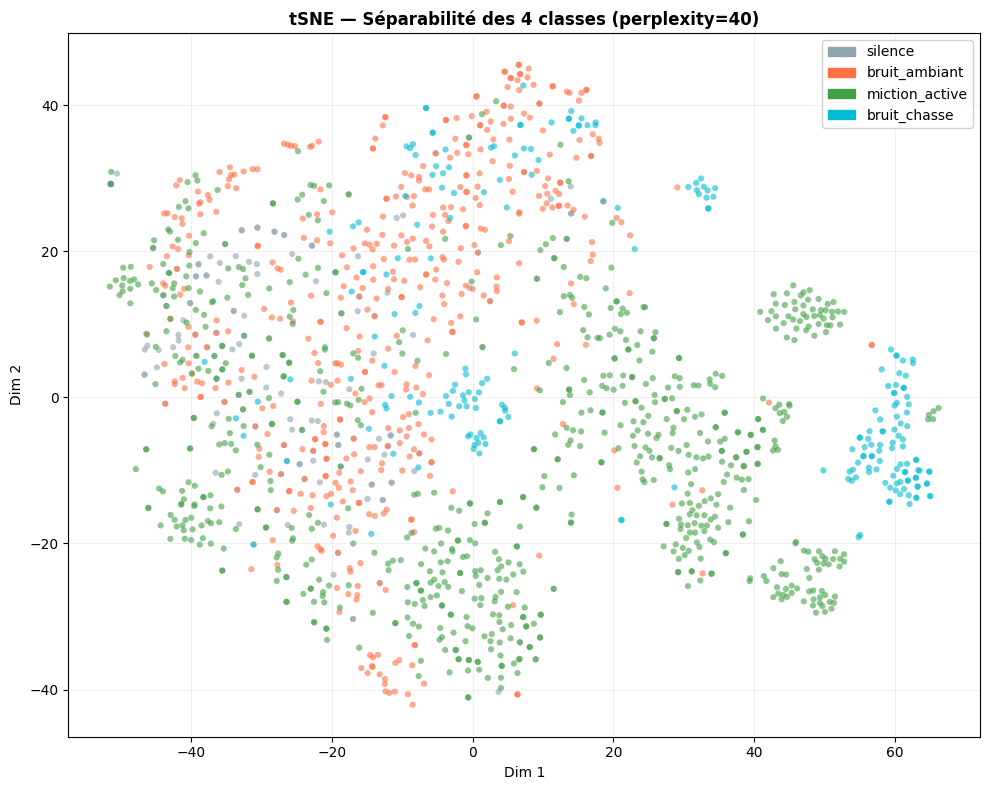

In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
import matplotlib.patches as mpatches

feat_cols = [c for c in df_features.columns if c not in
             ['fichier', 'segment_id', 't_start_s', 't_end_s', 'label']]
X = df_features[feat_cols].values
y = df_features['label'].values

COLORS_LABELS = {
    'silence':        '#90A4AE',
    'bruit_ambiant':  '#FF7043',
    'miction_active': '#43A047',
    'bruit_chasse':   '#00BCD4',
}

scaler = StandardScaler()
X_sc   = scaler.fit_transform(X)

print("Calcul tSNE (patience ~30s)...")
tsne   = TSNE(n_components=2, perplexity=40, random_state=42,
              max_iter=1000, learning_rate='auto', init='pca')
X_tsne = tsne.fit_transform(X_sc)
print(f"tSNE terminé — KL divergence : {tsne.kl_divergence_:.4f}")

fig, ax = plt.subplots(figsize=(10, 8))
ax.set_title('tSNE — Séparabilité des 4 classes (perplexity=40)',
             fontsize=12, fontweight='bold')

for lbl, col in COLORS_LABELS.items():
    mask = y == lbl
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
               c=col, s=20, alpha=0.6, edgecolors='none')

handles = [mpatches.Patch(color=col, label=lbl)
           for lbl, col in COLORS_LABELS.items()]
ax.legend(handles=handles, fontsize=10, framealpha=0.9)
ax.set_xlabel('Dim 1'); ax.set_ylabel('Dim 2')
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(f'{LAB_DIR}/tsne_4classes.png', dpi=130, bbox_inches='tight')
plt.show()

Dataset : 1623 segments | 39 features | 4 classes
Validation : 5-fold stratifiée → chaque fold : ~324 segments test

Classifieur            |  Accuracy |  Bal.Acc |  F1 macro |  Temps
Random Forest          |     0.792 |    0.709 |     0.731 |   4.3s
Gradient Boosting      |     0.780 |    0.700 |     0.719 | 105.7s
SVM (C=1, auto)        |     0.766 |    0.777 |     0.740 |   0.5s

Classement :


,Classifieur,Accuracy,Bal.Acc,F1 macro,F1 weighted,Temps(s)
0,"SVM (C=1, auto)",0.766,0.777,0.740,0.783,0.5
1,Random Forest,0.792,0.709,0.731,0.788,4.3
2,Gradient Boosting,0.780,0.700,0.719,0.777,105.7



RAPPORT DÉTAILLÉ — SVM (C=1, auto)
Accuracy          : 0.766
Balanced Accuracy : 0.777

                precision    recall  f1-score   support

 bruit_ambiant      0.727     0.695     0.711       463
  bruit_chasse      0.944     0.842     0.890       222
miction_active      0.931     0.781     0.850       782
       silence      0.377     0.788     0.510       156

      accuracy                          0.766      1623
     macro avg      0.745     0.777     0.740      1623
  weighted avg      0.822     0.766     0.783      1623



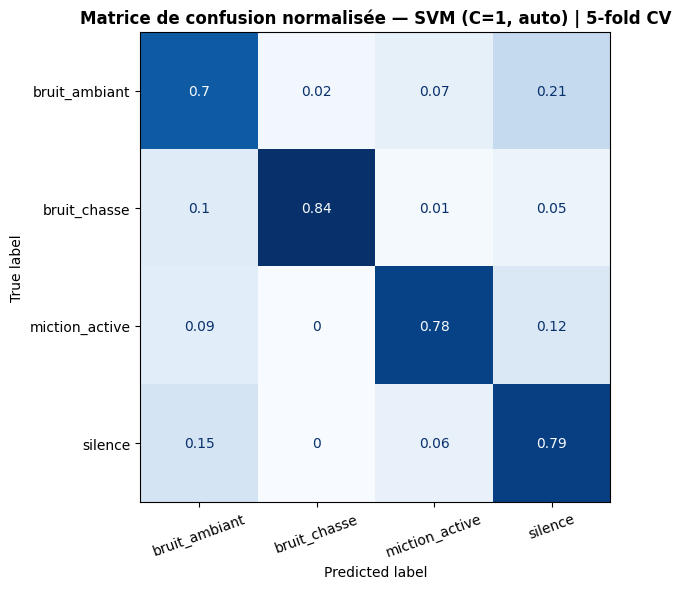

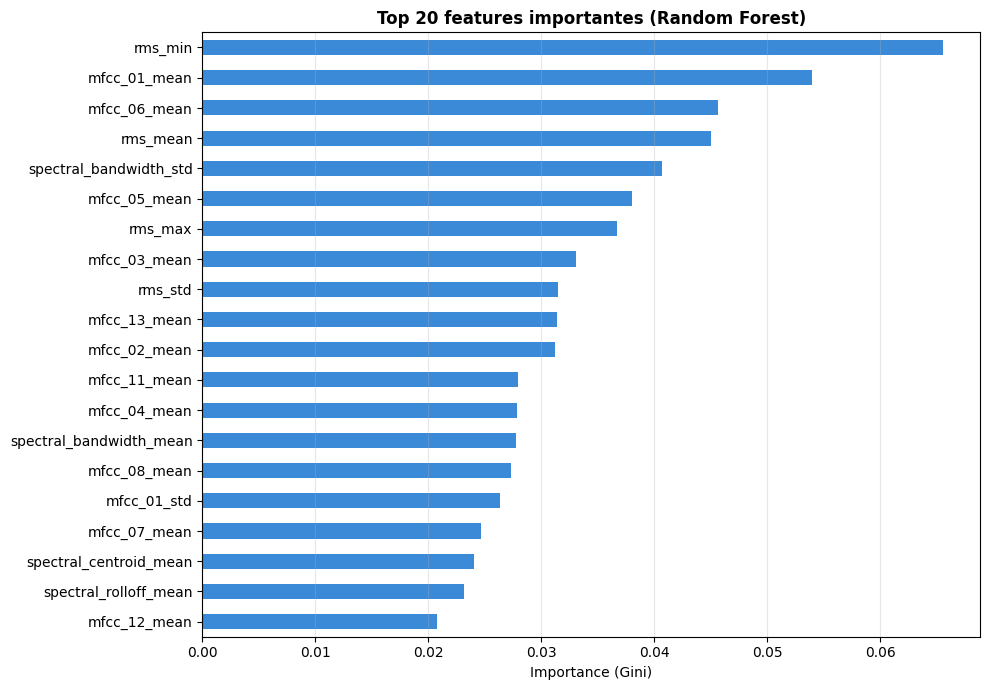


 Modèle final entraîné et sauvegardé
   Fichiers : modele_final.pkl | scaler_final.pkl | feature_cols.pkl


In [16]:

# ════════════════════════════════════════════════════════════════
# CLASSIFIEUR FINAL — 4 classes
# Validation croisée stratifiée 5-fold
# ════════════════════════════════════════════════════════════════
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                              f1_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)
import joblib, time

feat_cols = [c for c in df_features.columns if c not in
             ['fichier', 'segment_id', 't_start_s', 't_end_s', 'label']]
X      = df_features[feat_cols].values
y      = df_features['label'].values
scaler = StandardScaler()
X_sc   = scaler.fit_transform(X)

# ── Validation croisée 5-fold stratifiée ─────────────────────
# Chaque segment est prédit une fois par un modèle qui ne l'a pas vu
# Stratifié = proportions des classes respectées dans chaque fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"Dataset : {len(X)} segments | {len(feat_cols)} features | {len(np.unique(y))} classes")
print(f"Validation : 5-fold stratifiée → chaque fold : ~{len(X)//5} segments test\n")

classifieurs = {
    'Random Forest':     RandomForestClassifier(
                            n_estimators=200, class_weight='balanced',
                            random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(
                            n_estimators=200, max_depth=4, random_state=42),
    'SVM (C=1, auto)':   SVC(kernel='rbf', class_weight='balanced',
                            C=1, gamma='auto', random_state=42),
}

print("="*72)
print(f"{'Classifieur':22s} | {'Accuracy':>9} | {'Bal.Acc':>8} | {'F1 macro':>9} | {'Temps':>6}")
print("="*72)

resultats   = []
predictions = {}

for nom, clf in classifieurs.items():
    t0     = time.time()
    y_pred = cross_val_predict(clf, X_sc, y, cv=cv)
    duree  = time.time() - t0

    acc  = accuracy_score(y, y_pred)
    bal  = balanced_accuracy_score(y, y_pred)
    f1m  = f1_score(y, y_pred, average='macro')
    f1w  = f1_score(y, y_pred, average='weighted')

    resultats.append({
        'Classifieur': nom,
        'Accuracy':    round(acc, 3),
        'Bal.Acc':     round(bal, 3),
        'F1 macro':    round(f1m, 3),
        'F1 weighted': round(f1w, 3),
        'Temps(s)':    round(duree, 1)
    })
    predictions[nom] = y_pred
    print(f"{nom:22s} | {acc:9.3f} | {bal:8.3f} | {f1m:9.3f} | {duree:5.1f}s")

print("="*72)

# ── Tableau récapitulatif ─────────────────────────────────────
df_res   = pd.DataFrame(resultats).sort_values('Bal.Acc', ascending=False)
print("\nClassement :")
display(df_res.reset_index(drop=True))

# ── Meilleur classifieur → rapport détaillé ───────────────────
meilleur = df_res.iloc[0]['Classifieur']
y_pred   = predictions[meilleur]

print(f"\n{'='*55}")
print(f"RAPPORT DÉTAILLÉ — {meilleur}")
print(f"{'='*55}")
print(f"Accuracy          : {accuracy_score(y, y_pred):.3f}")
print(f"Balanced Accuracy : {balanced_accuracy_score(y, y_pred):.3f}")
print(f"\n{classification_report(y, y_pred, digits=3)}")

# ── Matrice de confusion normalisée  ────────────────
classes = sorted(np.unique(y))
cm      = confusion_matrix(y, y_pred, labels=classes)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(8, 6))
ax.set_title(f'Matrice de confusion normalisée — {meilleur} | 5-fold CV',
             fontsize=12, fontweight='bold')

ConfusionMatrixDisplay(cm_norm.round(2), display_labels=classes).plot(
    ax=ax, colorbar=False, cmap='Blues')
ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig(f'{LAB_DIR}/matrice_confusion_finale.png', dpi=130, bbox_inches='tight')
plt.show()
# ── Importance des features ───────────────────────────────────
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced',
                             random_state=42, n_jobs=-1)
rf.fit(X_sc, y)
importances = pd.Series(rf.feature_importances_, index=feat_cols).nlargest(20)

fig, ax = plt.subplots(figsize=(10, 7))
importances.sort_values().plot(kind='barh', ax=ax, color='#1976D2', alpha=0.85)
ax.set_title('Top 20 features importantes (Random Forest)', fontweight='bold')
ax.set_xlabel('Importance (Gini)')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(f'{LAB_DIR}/feature_importance.png', dpi=130, bbox_inches='tight')
plt.show()

# ── Sauvegarder le meilleur modèle ────────────────────────────
best_clf = classifieurs[meilleur]
best_clf.fit(X_sc, y)
joblib.dump(best_clf,  f'{LAB_DIR}/modele_final.pkl')
joblib.dump(scaler,    f'{LAB_DIR}/scaler_final.pkl')
joblib.dump(feat_cols, f'{LAB_DIR}/feature_cols.pkl')
print(f"\n Modèle final entraîné et sauvegardé")
print(f"   Fichiers : modele_final.pkl | scaler_final.pkl | feature_cols.pkl")

In [17]:
# ════════════════════════════════════════════════════════════════
# CALCUL DES INDICATEURS MÉDICAUX
# Sur chaque enregistrement labélisé et prédit
# ════════════════════════════════════════════════════════════════

def calculer_indicateurs(nom_fichier, labels_pred, segment_ms=500):
    """
    Calcule les indicateurs médicaux à partir des labels prédits.
    
    Entrée  : liste de labels prédits pour chaque segment de 500ms
    Sortie  : dictionnaire d'indicateurs médicaux
    """
    seg_s  = segment_ms / 1000
    n_segs = len(labels_pred)
    dur_totale = n_segs * seg_s

    # ── Comptage des segments par classe ─────────────────────
    from collections import Counter
    counts = Counter(labels_pred)

    n_miction  = counts.get('miction_active', 0)
    n_silence  = counts.get('silence', 0)
    n_ambiant  = counts.get('bruit_ambiant', 0)
    n_chasse   = counts.get('bruit_chasse', 0)

    # ── Indicateur 1 : Durée totale de miction ────────────────
    duree_miction_s  = n_miction * seg_s

    # ── Indicateur 2 : Épisodes de miction ────────────────────
    # Un épisode = suite consécutive de segments miction_active
    episodes = []
    en_miction = False
    debut_ep   = 0

    for i, lbl in enumerate(labels_pred):
        if lbl == 'miction_active' and not en_miction:
            en_miction = True
            debut_ep   = i
        elif lbl != 'miction_active' and en_miction:
            en_miction = False
            duree_ep   = (i - debut_ep) * seg_s
            episodes.append({
                't_debut': round(debut_ep * seg_s, 2),
                't_fin':   round(i * seg_s, 2),
                'duree':   round(duree_ep, 2)
            })
    # Dernier épisode si se termine à la fin
    if en_miction:
        duree_ep = (n_segs - debut_ep) * seg_s
        episodes.append({
            't_debut': round(debut_ep * seg_s, 2),
            't_fin':   round(n_segs * seg_s, 2),
            'duree':   round(duree_ep, 2)
        })

    n_episodes      = len(episodes)
    duree_max_ep    = max([e['duree'] for e in episodes], default=0)
    duree_moy_ep    = round(np.mean([e['duree'] for e in episodes]), 2) if episodes else 0

    # ── Indicateur 3 : Type de miction ────────────────────────
    # Basé sur la continuité des épisodes détectés
    if n_episodes == 0:
        type_miction = 'non_detectee'
    elif n_episodes == 1 and duree_miction_s >= 5.0:
        type_miction = 'jet_continu'
    elif n_episodes == 2 and duree >= 10:
        type_miction = 'jet_continu'
    elif n_episodes >= 3:
        type_miction = 'jet_hache'
    else:
        type_miction = 'jet_faible'

    # ── Indicateur 4 : Ratio miction / enregistrement ─────────
    ratio_miction = round(duree_miction_s / dur_totale, 3) if dur_totale > 0 else 0

    # ── Indicateur 5 : Présence chasse d'eau ──────────────────
    chasse_detectee = n_chasse > 0

    return {
        'fichier':           nom_fichier,
        # Indicateurs principaux
        'duree_miction_s':   round(duree_miction_s, 2),
        'nb_episodes':       n_episodes,
        'type_miction':      type_miction,
        # Indicateurs secondaires
        'duree_max_episode': duree_max_ep,
        'duree_moy_episode': duree_moy_ep,
        'ratio_miction':     ratio_miction,
        'chasse_detectee':   chasse_detectee,
        # Détail des épisodes
        'episodes':          episodes,
        # Comptages bruts
        'n_segs_total':      n_segs,
        'n_segs_miction':    n_miction,
        'n_segs_silence':    n_silence,
        'n_segs_ambiant':    n_ambiant,
        'n_segs_chasse':     n_chasse,
    }


# ── Appliquer sur tous les enregistrements ────────────────────
print("Calcul des indicateurs médicaux...")
print("="*65)

# Charger le meilleur modèle
import joblib
svm_final   = joblib.load(f'{LAB_DIR}/modele_final.pkl')
scaler_load = joblib.load(f'{LAB_DIR}/scaler_final.pkl')
feat_load   = joblib.load(f'{LAB_DIR}/feature_cols.pkl')

tous_indicateurs = []

for nom_fichier in sorted(dataset.keys()):
    rec    = dataset[nom_fichier]
    labels = all_labels.get(nom_fichier, [])
    if not labels:
        continue

    # Récupérer les features de ce fichier
    mask   = df_features['fichier'] == nom_fichier
    X_file = df_features[mask][feat_load].values
    if len(X_file) == 0:
        continue

    # Prédire
    X_file_sc  = scaler_load.transform(X_file)
    labels_pred = svm_final.predict(X_file_sc)

    # Calculer les indicateurs
    indic = calculer_indicateurs(nom_fichier, labels_pred)
    tous_indicateurs.append(indic)

    # Affichage résumé
    print(f"{nom_fichier:40s} | {indic['duree_miction_s']:5.1f}s "
          f"| {indic['nb_episodes']} épisode(s) "
          f"| {indic['type_miction']:15s} "
          f"| chasse={'oui' if indic['chasse_detectee'] else 'non'}")

print("="*65)

# ── DataFrame des indicateurs ─────────────────────────────────
df_indic = pd.DataFrame([{k: v for k, v in ind.items() if k != 'episodes'}
                          for ind in tous_indicateurs])

print(f"\nStatistiques globales :")
print(f"  Durée miction moy  : {df_indic['duree_miction_s'].mean():.1f}s")
print(f"  Durée miction min  : {df_indic['duree_miction_s'].min():.1f}s")
print(f"  Durée miction max  : {df_indic['duree_miction_s'].max():.1f}s")
print(f"\nDistribution types :")
print(df_indic['type_miction'].value_counts().to_string())

# ── Sauvegarder ───────────────────────────────────────────────
csv_indic = f'{LAB_DIR}/indicateurs_medicaux.csv'
df_indic.to_csv(csv_indic, index=False, encoding='utf-8-sig')
print(f"\nIndicateurs sauvegardés → {csv_indic}")
display(df_indic[['fichier','duree_miction_s','nb_episodes',
                   'type_miction','ratio_miction','chasse_detectee']])

Calcul des indicateurs médicaux...
Audio_1                                  |   8.5s | 7 épisode(s) | jet_hache       | chasse=oui
Audio_10                                 |  14.5s | 4 épisode(s) | jet_hache       | chasse=oui
Audio_11                                 |  12.5s | 2 épisode(s) | jet_faible      | chasse=oui
Audio_12                                 |  14.0s | 5 épisode(s) | jet_hache       | chasse=oui
Audio_13                                 |  12.5s | 2 épisode(s) | jet_faible      | chasse=oui
Audio_14                                 |  16.0s | 1 épisode(s) | jet_continu     | chasse=oui
Audio_15                                 |  12.0s | 4 épisode(s) | jet_hache       | chasse=oui
Audio_16                                 |  17.0s | 1 épisode(s) | jet_continu     | chasse=oui
Audio_17                                 |  16.0s | 3 épisode(s) | jet_hache       | chasse=non
Audio_18                                 |  23.5s | 2 épisode(s) | jet_faible      | chasse=oui
Audio

,fichier,duree_miction_s,nb_episodes,type_miction,ratio_miction,chasse_detectee
0,Audio_1,8.5,7,jet_hache,0.202,True
1,Audio_10,14.5,4,jet_hache,0.453,True
2,Audio_11,12.5,2,jet_faible,0.362,True
3,Audio_12,14.0,5,jet_hache,0.354,True
4,Audio_13,12.5,2,jet_faible,0.362,True
5,Audio_14,16.0,1,jet_continu,0.333,True
6,Audio_15,12.0,4,jet_hache,0.324,True
7,Audio_16,17.0,1,jet_continu,0.400,True
8,Audio_17,16.0,3,jet_hache,0.615,False
9,Audio_18,23.5,2,jet_faible,0.627,True


In [18]:
# ── Règle améliorée + lissage intégré ────────────────────────
def classifier_type_miction(n_episodes, duree_s):
    """
    Règle de classification basée sur nb épisodes ET durée totale.
    
    jet_continu : flux long et continu (1-2 épisodes, durée > 8s)
    jet_hache   : flux fragmenté      (3+ épisodes)
    jet_faible  : flux court/faible   (durée < 8s)
    """
    if duree_s < 5.0:
        return 'jet_faible'                        # trop court → faible
    elif n_episodes >= 3:
        return 'jet_hache'                         # fragmenté → haché
    elif n_episodes <= 2 and duree_s >= 8.0:
        return 'jet_continu'                       # long et peu fragmenté → continu
    else:
        return 'jet_faible'                        # courte durée → faible


# ── Recalculer tous les indicateurs avec lissage + nouvelle règle ──
print("Indicateurs finaux — lissage gap=2 + règle améliorée")
print("="*70)

tous_indicateurs_final = []

for nom_fichier in sorted(dataset.keys()):
    mask   = df_features['fichier'] == nom_fichier
    X_file = df_features[mask][feat_load].values
    if len(X_file) == 0:
        continue

    # Prédire + lisser
    X_sc_file   = scaler_load.transform(X_file)
    labels_brut = list(svm_final.predict(X_sc_file))
    labels_liss = lisser_predictions(labels_brut, gap_max_segs=2)

    # Calculer indicateurs de base
    indic = calculer_indicateurs(nom_fichier, labels_liss)

    # Appliquer nouvelle règle de type
    indic['type_miction'] = classifier_type_miction(
        indic['nb_episodes'], indic['duree_miction_s']
    )
    tous_indicateurs_final.append(indic)

    print(f"{nom_fichier:40s} | {indic['duree_miction_s']:5.1f}s "
          f"| {indic['nb_episodes']} ep "
          f"| {indic['type_miction']:15s} "
          f"| chasse={'oui' if indic['chasse_detectee'] else 'non'}")

print("="*70)

# ── Statistiques finales ──────────────────────────────────────
df_final = pd.DataFrame([{k:v for k,v in i.items() if k != 'episodes'}
                           for i in tous_indicateurs_final])

print(f"\nDistribution types (finale) :")
print(df_final['type_miction'].value_counts().to_string())
print(f"\nDurée miction — moy={df_final['duree_miction_s'].mean():.1f}s  "
      f"min={df_final['duree_miction_s'].min():.1f}s  "
      f"max={df_final['duree_miction_s'].max():.1f}s")

# Sauvegarder
df_final.to_csv(f'{LAB_DIR}/indicateurs_medicaux_final.csv',
                index=False, encoding='utf-8-sig')
print(f"\n Indicateurs finaux sauvegardés")
display(df_final[['fichier','duree_miction_s','nb_episodes',
                   'type_miction','ratio_miction','chasse_detectee']])

Indicateurs finaux — lissage gap=2 + règle améliorée


NameError: name 'lisser_predictions' is not defined

In [ ]:
# Tester gap de lissage plus grand
for gap in [2, 3, 4, 5]:
    types = []
    for nom_fichier in sorted(dataset.keys()):
        mask   = df_features['fichier'] == nom_fichier
        X_file = df_features[mask][feat_load].values
        if len(X_file) == 0:
            continue
        X_sc_file   = scaler_load.transform(X_file)
        labels_brut = list(svm_final.predict(X_sc_file))
        labels_liss = lisser_predictions(labels_brut, gap_max_segs=gap)
        indic       = calculer_indicateurs(nom_fichier, labels_liss)
        
        if indic['duree_miction_s'] < 8.0:
            t = 'jet_faible'
        elif indic['nb_episodes'] >= 2:
            t = 'jet_hache'
        else:
            t = 'jet_continu'
        types.append(t)
    
    from collections import Counter
    print(f"Gap={gap} segs ({gap*500}ms) : {dict(Counter(types))}")

In [ ]:
# ════════════════════════════════════════════════════════════════
# PARAMÈTRES DÉFINITIFS — Pipeline indicateurs médicaux
# ════════════════════════════════════════════════════════════════
GAP_LISSAGE   = 4    # Fusion épisodes séparés par < 2s
SEUIL_HACHE   = 2    # >= 2 épisodes après lissage = jet haché
SEUIL_FAIBLE  = 8.0  # < 8s = jet faible

def pipeline_indicateurs(nom_fichier, X_file, svm_model, scaler,
                          feat_cols, gap=GAP_LISSAGE):
    """
    Pipeline complet : features → prédiction → lissage → indicateurs.
    Utilisable en production sur tout nouvel enregistrement.
    """
    # Prédiction
    X_sc        = scaler.transform(X_file)
    labels_brut = list(svm_model.predict(X_sc))

    # Lissage
    labels_liss = lisser_predictions(labels_brut, gap_max_segs=gap)

    # Indicateurs de base
    indic = calculer_indicateurs(nom_fichier, labels_liss)

    # Type final
    if indic['duree_miction_s'] < SEUIL_FAIBLE:
        indic['type_miction'] = 'jet_faible'
    elif indic['nb_episodes'] >= SEUIL_HACHE:
        indic['type_miction'] = 'jet_hache'
    else:
        indic['type_miction'] = 'jet_continu'

    return indic

# ── Recalculer tous les indicateurs finaux ────────────────────
print("INDICATEURS MÉDICAUX FINAUX")
print(f"Paramètres : gap={GAP_LISSAGE} segs ({GAP_LISSAGE*500}ms) | "
      f"seuil_hache={SEUIL_HACHE} ep | seuil_faible={SEUIL_FAIBLE}s")
print("="*70)

tous_indic_final = []
for nom_fichier in sorted(dataset.keys()):
    mask   = df_features['fichier'] == nom_fichier
    X_file = df_features[mask][feat_load].values
    if len(X_file) == 0:
        continue
    indic = pipeline_indicateurs(nom_fichier, X_file,
                                  svm_final, scaler_load, feat_load)
    tous_indic_final.append(indic)
    print(f"{nom_fichier:40s} | {indic['duree_miction_s']:5.1f}s "
          f"| {indic['nb_episodes']} ep "
          f"| {indic['type_miction']:12s} "
          f"| chasse={'oui' if indic['chasse_detectee'] else 'non'}")

print("="*70)

# ── Statistiques finales ──────────────────────────────────────
df_indic_final = pd.DataFrame([{k:v for k,v in i.items() if k != 'episodes'}
                                 for i in tous_indic_final])

print(f"\nDistribution types :")
print(df_indic_final['type_miction'].value_counts().to_string())
print(f"\nDurée miction :")
print(f"  Moyenne : {df_indic_final['duree_miction_s'].mean():.1f}s")
print(f"  Min     : {df_indic_final['duree_miction_s'].min():.1f}s")
print(f"  Max     : {df_indic_final['duree_miction_s'].max():.1f}s")
print(f"  Écart-type : {df_indic_final['duree_miction_s'].std():.1f}s")

# ── Sauvegarder paramètres + résultats ────────────────────────
params = {
    'gap_lissage_segs':   GAP_LISSAGE,
    'gap_lissage_ms':     GAP_LISSAGE * 500,
    'seuil_hache_ep':     SEUIL_HACHE,
    'seuil_faible_s':     SEUIL_FAIBLE,
    'segment_ms':         500,
}
import json
with open(f'{LAB_DIR}/params_pipeline.json', 'w') as f:
    json.dump(params, f, indent=2)

df_indic_final.to_csv(f'{LAB_DIR}/indicateurs_medicaux_final.csv',
                       index=False, encoding='utf-8-sig')

print(f"\nParamètres sauvegardés → params_pipeline.json")
print(f"Indicateurs sauvegardés → indicateurs_medicaux_final.csv")
display(df_indic_final[['fichier','duree_miction_s','nb_episodes',
                          'type_miction','ratio_miction','chasse_detectee']])